In [1]:
import numpy as onp
import sympy as sp
from pathlib import Path
import sys
_project_root: Path = Path.cwd().resolve()
sys.path.insert(0, str(_project_root.parents[1]))
import src.symmetry as sym
from src.categorization import show_latex_bmatrix, show_latex_eqn, latex_bmatrix_vec, cyclic_power_rep
from src.bases import CanonBasis4x4
from src.permutations import Permutation, PermutationGroup, PermElt
import src.permutations as perms
NDArray = onp.ndarray


/Users/jakeschaefer/Desktop/Research_Stuff/mat_sci/crystals/src/permutations.py:465: SyntaxWarning: "is not" with 'str' literal. Did you mean "!="?
  obj._name = name if name is not '' else to_cycle_notation(obj)


The group $\mathcal{M}$ is the one generated by the following two permutations:
$$
  \sigma = (1,2,3,4,5,6,7,8,9,10,11)\quad\text{and}\quad\tau = (3,7,11,8)(4,10,5,6),
$$
so
$$
  \mathcal{M}:=\langle\sigma,\tau\rangle
$$

The eigenvalues of a finite-dimensional linear operator $A$ are determined by its characteristic polynomial:
$$
  p_A(t) = t^n + a_{n-1}t^{n-1}+\dots + a_1 t + a_0,
$$
which is another conjugacy invariant. Also, note that
$$
  a_{n-1}=-(\lambda_1+\dots+\lambda_n)=-\mathrm{Tr}A
$$
and
$$
  a_0 = (-1)^n\lambda_1\cdot\cdots\cdot\lambda_n = (-1)^n \mathrm{det}A
$$

In [5]:
N = 11

# for characteristic polynomial
t = sp.Symbol('t')

σ = '(1,2,3,4,5,6,7,8,9,10,11)'
τ_1 = '(3,7,11,8)'
τ_2 = '(4,10,5,6)'
τ = τ_1 + τ_2

r1 = '(1,6,4,3)'
r2 = '(2,10,11,9)'

σ_perm = perms.from_cycle_notation(σ)
τ_perm = perms.from_cycle_notation(τ, degree=N)

# subset of S_11
M = perms.PermutationGroup.generated((σ_perm, τ_perm))


for g in M.conjugacy_class_representatives():
  print(g, perms.to_cycles(g), perms.cycle_type(g))

D = M.commutator_subgroup()
print(D.order)

(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10) () (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1)
(0, 1, 2, 4, 9, 8, 10, 3, 6, 7, 5) ((4, 5, 10, 8), (6, 9, 7, 11)) (4, 4, 1, 1, 1)
(0, 1, 2, 9, 7, 6, 5, 4, 10, 3, 8) ((4, 10), (5, 8), (6, 7), (9, 11)) (2, 2, 2, 2, 1, 1, 1)
(0, 1, 3, 9, 10, 4, 8, 6, 7, 2, 5) ((3, 4, 10), (5, 11, 6), (7, 9, 8)) (3, 3, 3, 1, 1)
(0, 2, 1, 4, 5, 10, 8, 6, 3, 7, 9) ((2, 3), (4, 5, 6, 11, 10, 8, 7, 9)) (8, 2, 1)
(0, 2, 1, 7, 6, 8, 10, 5, 9, 4, 3) ((2, 3), (4, 8, 6, 9, 10, 5, 7, 11)) (8, 2, 1)
(0, 2, 3, 7, 8, 9, 1, 6, 5, 10, 4) ((2, 3, 4, 8, 7), (5, 9, 6, 10, 11)) (5, 5, 1)
(1, 0, 3, 5, 6, 4, 8, 10, 2, 7, 9) ((1, 2), (3, 4, 6, 5, 7, 9), (8, 11, 10)) (6, 3, 2)
(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0) ((1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11),) (11,)
(1, 2, 3, 5, 10, 9, 0, 4, 7, 8, 6) ((1, 2, 3, 4, 6, 10, 9, 8, 5, 11, 7),) (11,)
7920


In [11]:
print(len(M))

7920


In [3]:
class_sizes_M = M.class_sizes_by_cycle_type()
classes_M = M.classes_by_cycle_type()
print(classes_M)
class_order_M = class_sizes_M.keys()
print(class_sizes_M)

class CharM:
  def __init__(self, data: dict):
    self.data = data

  def __getitem__(self, key):
    return self.data[key]

  def __or__(self, other):
    r""" Inner product on S5!!! """
    return sum(cs * self[ct] * other[ct] for ct, cs in class_sizes_M.items()) / len(M)

  def values_on_classes(self):
    return [self[ct] for ct in class_order_M]

  def decompose(self, irreducible_basis: dict[str, 'CharM']):
    r""" decompose_class_function """
    return {name: (self|chi) for name, chi in irreducible_basis.items()}

# trivial
chi_U = CharM({ct: 1 for ct in class_order_M})
# alternating
chi_U_alt = CharM({ct: perms.sgn(classes_M[ct][0]) for ct in class_order_M})


{(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1): ((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10),), (11,): ((1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0), (1, 2, 7, 10, 6, 4, 0, 3, 9, 5, 8), (1, 6, 9, 5, 3, 10, 2, 8, 4, 7, 0), (1, 7, 10, 6, 2, 9, 0, 5, 3, 4, 8), (1, 7, 0, 4, 9, 6, 8, 10, 3, 2, 5), (2, 8, 1, 5, 10, 7, 9, 0, 4, 3, 6), (7, 0, 4, 9, 6, 8, 10, 3, 2, 5, 1), (8, 9, 3, 7, 5, 6, 1, 4, 10, 0, 2), (8, 2, 6, 4, 5, 0, 3, 9, 10, 1, 7), (8, 9, 1, 0, 6, 7, 2, 3, 10, 5, 4), (8, 0, 10, 5, 6, 1, 2, 9, 4, 3, 7), (7, 8, 3, 5, 10, 4, 2, 1, 9, 6, 0), (8, 3, 1, 0, 2, 10, 7, 5, 6, 4, 9), (8, 3, 7, 4, 10, 0, 9, 1, 6, 2, 5), (4, 10, 8, 2, 6, 1, 9, 3, 0, 5, 7), (9, 7, 1, 5, 0, 8, 2, 10, 4, 6, 3), (4, 10, 9, 5, 1, 2, 7, 8, 0, 6, 3), (9, 8, 4, 0, 1, 6, 7, 10, 5, 2, 3), (10, 7, 6, 2, 5, 3, 9, 0, 1, 8, 4), (6, 5, 1, 4, 2, 8, 10, 0, 7, 3, 9), (9, 6, 3, 4, 1, 7, 10, 8, 0, 2, 5), (9, 6, 10, 2, 7, 4, 5, 3, 0, 1, 8), (6, 10, 3, 8, 5, 7, 9, 2, 1, 4, 0), (10, 3, 8, 5, 7, 9, 2, 1, 4, 0, 6), (7, 0, 10, 5, 8, 9, 1, 4, 2, 6, 3), (10, 9, 4, 7, 8, 

We know that since the image of our representations are permutations, they must be unitary. Therefore, they have eigenvalues lying on the unit circle. In particular, since $G$ is finite, every element $g\in G$ must have finite order. Thus, for some $n$, we have 
$$
\rho(g)^n = \rho(g^n)=\rho(e)=\mathbb{I},
$$
so the characteristic polynomial of $\rho(g)$ will have eigenvalues that are $n$-th roots of unity! Let $v$ be an eigenvector of $\rho(g)$, so 
$$
 \mathbb{I}v = \rho(g)^n v = \lambda^n v = v
$$


The characters of $G$ will be sums of the (powers of) $n$-th roots of unity
$$
  \chi(g) = \sum_i \zeta_n^{r_i}
$$

Alsol, characteristic polyns are conjugacy invariants.


suppose we have some irreducible character $\chi$ of $G$, and let $\sigma\in\mathrm{Gal}(\mathbb{Q}(\zeta_N)/\mathbb{Q})$. Then, we can define a new function $\sigma_\chi$ by the composition of $\sigma$ and $\chi$ as 
$$
\sigma_\chi:G\to\mathbb{C},\quad \sigma_\chi(g):=(\sigma\circ\chi)(g).
$$
then, $\sigma_\chi$ is again an irreducible character.

In [99]:
character_types: dict[int, set[tuple[int, ...]]] = {}


for g in M.conjugacy_class_representatives():
  c_type = perms.cycle_type(g)
  order = max(c_type)

  # g has order m => ρ(g) has eigenvalues that are m-th roots of unity
  # thus, the character is also a sum of roots of unity
  print(g, perms.to_cycle_notation(g), c_type, order)
  An = perms.identity(M.degree)
  # 

  for _ in range(order):
    An = perms.compose(An, g)
    char = perms.character(An)
    if char not in character_types:
      character_types[char] = set({An})
    else:
      character_types[char] |= set({An})

    print(perms.to_cycle_notation(An), char)
  print()


character_types_sum = dict(zip(
  character_types.keys(), 
  tuple(map(lambda x: len(x), character_types.values()))
))

print(character_types_sum)
ct_2 = dict(zip(
  character_types.keys(), 
  tuple(map(lambda x: len(x)**2, character_types.values()))
))
print(ct_2)
print(sum(ct_2.values()))

print(character_types[11])



(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10) () (1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1) 1
() 11

(0, 1, 2, 4, 9, 8, 10, 3, 6, 7, 5) (4,5,10,8)(6,9,7,11) (4, 4, 1, 1, 1) 4
(4,5,10,8)(6,9,7,11) 3
(4,10)(5,8)(6,7)(9,11) 3
(4,8,10,5)(6,11,7,9) 3
() 11

(0, 1, 2, 9, 7, 6, 5, 4, 10, 3, 8) (4,10)(5,8)(6,7)(9,11) (2, 2, 2, 2, 1, 1, 1) 2
(4,10)(5,8)(6,7)(9,11) 3
() 11

(0, 1, 3, 9, 10, 4, 8, 6, 7, 2, 5) (3,4,10)(5,11,6)(7,9,8) (3, 3, 3, 1, 1) 3
(3,4,10)(5,11,6)(7,9,8) 2
(3,10,4)(5,6,11)(7,8,9) 2
() 11

(0, 2, 1, 4, 5, 10, 8, 6, 3, 7, 9) (2,3)(4,5,6,11,10,8,7,9) (8, 2, 1) 8
(2,3)(4,5,6,11,10,8,7,9) 1
(4,6,10,7)(5,11,8,9) 3
(2,3)(4,11,7,5,10,9,6,8) 1
(4,10)(5,8)(6,7)(9,11) 3
(2,3)(4,8,6,9,10,5,7,11) 1
(4,7,10,6)(5,9,8,11) 3
(2,3)(4,9,7,8,10,11,6,5) 1
() 11

(0, 2, 1, 7, 6, 8, 10, 5, 9, 4, 3) (2,3)(4,8,6,9,10,5,7,11) (8, 2, 1) 8
(2,3)(4,8,6,9,10,5,7,11) 1
(4,6,10,7)(5,11,8,9) 3
(2,3)(4,9,7,8,10,11,6,5) 1
(4,10)(5,8)(6,7)(9,11) 3
(2,3)(4,5,6,11,10,8,7,9) 1
(4,7,10,6)(5,9,8,11) 3
(2,3)(4,11,7,5,10,9,6,8) 1
() 11

(

In [ ]:
r3 = perms.from_cycle_notation('(4, 5, 10, 8)', degree=N)

r3_2 = perms.compose(r3, r3)
print(perms.to_cycle_notation(r3_2))


print(onp.prod(perms.cycle_type(r3)))


(4,10)(5,8)
4


In [ ]:
An = perms.identity(M.degree)
for _ in range(onp.prod(perms.cycle_type(r3))):
  An = perms.compose(An, r3)
  char = perms.character(An)
  # onp.trace(perms.perm_hom(An))
  
  print(perms.to_cycle_notation(An), char)
  print()

(4,5,10,8) 7

(4,10)(5,8) 7

(4,8,10,5) 7

() 11



### TODO

- ring structure
- 

### Notes:

Decomposing a rep $V$ over $\mathbb{C}$ into a sum of irreps 
$$
V=V_1\oplus\cdots\oplus V_r
$$
proceeds via a tree-like branching structure through Maschke's theorem by decomposing $V=W\oplus W'$ and analyzing each (c.f. proof of Maschke's theorem in Claudio notes)


Galois Theory controls how irreps descend from $\mathbb{C}$ to smaller fields. 

11


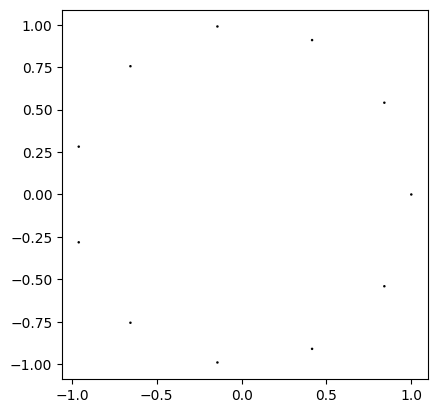

3


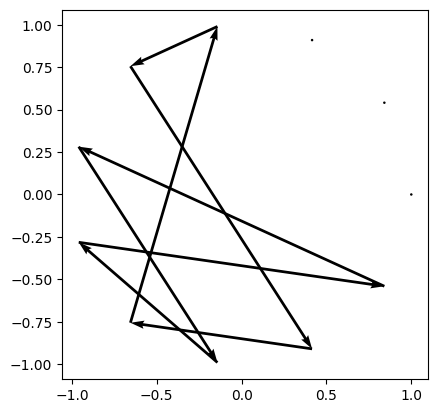

3


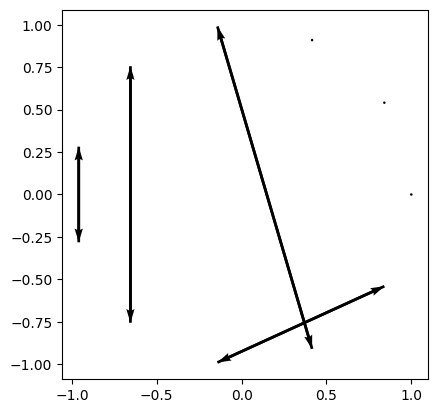

2


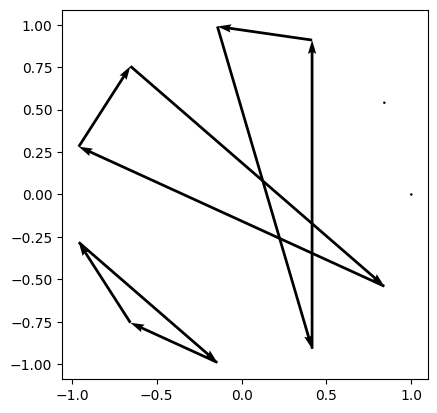

1


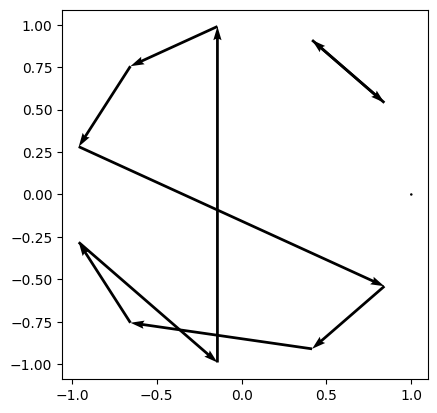

1


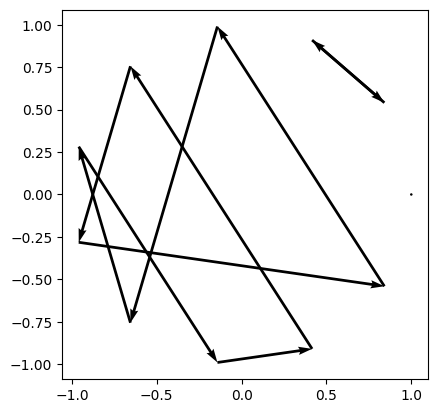

1


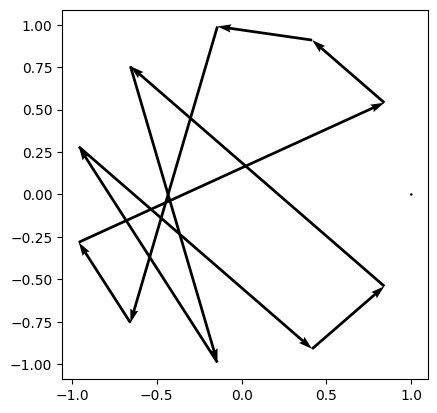

0


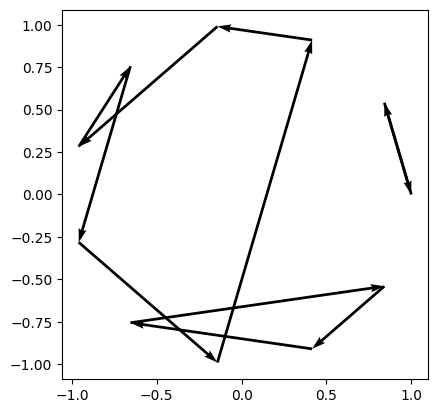

0


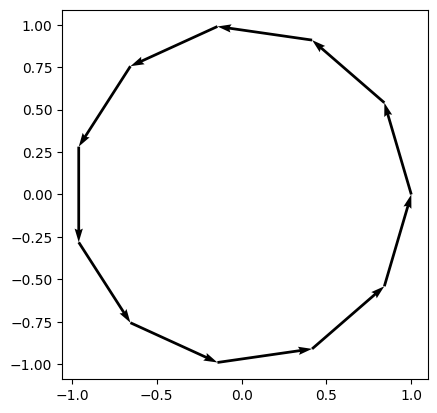

0


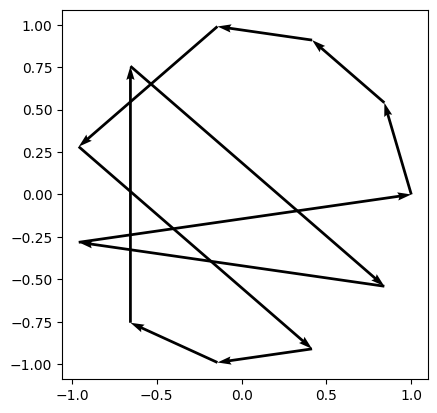

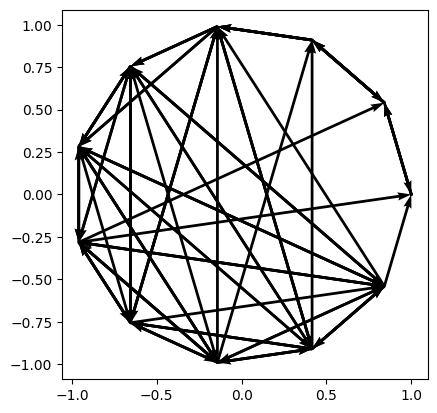

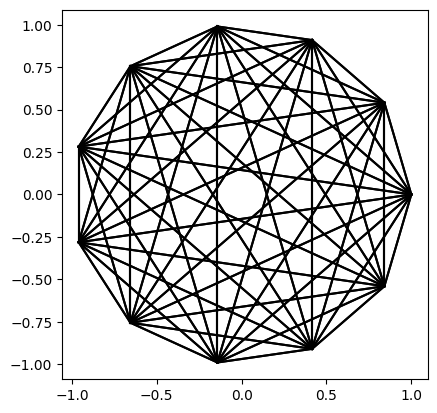

In [10]:
import matplotlib.pyplot as plt

vertices_c = [onp.exp(1j * 2*onp.pi*n/N) for n in range(N)]
verts_x = [v.real for v in vertices_c]
verts_y = [v.imag for v in vertices_c]

# verts = onp.array(list(zip(verts_x, verts_y)))
verts = onp.array(vertices_c)
verts_diag = onp.diag(verts)

# if we write the set of vertices X = {e_0, ..., e_10}, and we can talk about the action of M on C[X]
# somehow, the symmetric e_0+...+e_10 should lie in the center of the 11-gon I think? what does this subspace look like?
# we talk about formal sums here... we want a basis B(X) of X such that M acts via its irreps., 
# i.e., that M is decomposed via its irreps in this basis

# V^G = span{e_0+...+e_10}


# plt.plot(verts_x + [verts_x[0]], verts_y + [verts_y[0]])

# TODO define a "group action" class to formalize this 
# - should automatically conjugate when apply operation to its set of action
def get_action(g):
  rep = perms.perm_hom(g)
  return lambda v: onp.linalg.inv(rep) @ v @ rep




for g in M.conjugacy_class_representatives():
  v_g = get_action(g)(verts_diag)
  v_g_diag = onp.diag(v_g)
  diff = v_g_diag - verts
  # print(diff)
  print(onp.sum(diff ==0))
  for i in range(N):
    plt.quiver(verts[i].real, verts[i].imag, (diff[i].real), (diff[i].imag), scale_units='xy', scale=1)
    # plt.plot((verts[i].real, v_g_diag[i].real), (verts[i].imag, v_g_diag[i].imag), c='k')

  plt.gca().set_aspect('equal')
  plt.show()

for g in M.conjugacy_class_representatives():
  v_g = get_action(g)(verts_diag)
  v_g_diag = onp.diag(v_g)
  diff = v_g_diag - verts
  # print(diff)
  # print(onp.sum(diff ==0))
  for i in range(N):
    plt.quiver(verts[i].real, verts[i].imag, (diff[i].real), (diff[i].imag), scale_units='xy', scale=1)
    # plt.plot((verts[i].real, v_g_diag[i].real), (verts[i].imag, v_g_diag[i].imag), c='k')

plt.gca().set_aspect('equal')
plt.show()


for i in range(N):
  for j in range(N):
    plt.plot((verts_x[i], verts_x[j]), (verts_y[i], verts_y[j]), c='k')

plt.gca().set_aspect('equal')
plt.show()



